# SV and OA author comparison 

here we used the NEW run (OpenAlex methodology) 
- see `authors_RERUN.ipynb` for methodology

In [136]:
# import libraries 

import pandas as pd
import numpy as np
from scipy import stats
import json
import ast
import fuzzywuzzy
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
from datetime import datetime
from tqdm import tqdm 
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [137]:
oa_auths = pd.read_csv("./OA_auths_20-24.csv")
sv_auths = pd.read_csv("../sv_authors_20-24_deduplicated.csv")

In [138]:
# print just to get the idea of size

print("all authors lengths:")
print(len(oa_auths))
print(len(sv_auths))

all authors lengths:
7928
6362


In [139]:
oa_auths.columns

Index(['OpenAlex ID', 'ORCID', 'Name', 'Alt Names', 'Publications',
       'Citations', 'h-index', 'Number of Institutions', 'Topic'],
      dtype='object')

In [140]:
oa_auths['first_names'] = oa_auths['Name'].apply(lambda x: str.split(x, ' ')[:-1])
oa_auths['first_names'] = oa_auths['first_names'].apply(lambda x: " ".join(x).lower())
oa_auths['last_name'] = oa_auths['Name'].apply(lambda x: str.split(x, ' ')[-1].lower())
oa_auths['last_init'] = oa_auths['last_name'].apply(lambda x: str(x)[0].lower())
oa_auths['name_raw'] = oa_auths['Name'].apply(lambda x: str.lower(x))
oa_auths['id'] = oa_auths['OpenAlex ID']

oa_auths['fi_ln'] = oa_auths['first_names'].apply(
    lambda x: str(x)[0] if x else ''
) + ' ' + oa_auths['last_name']
#oa_auths

In [141]:
sv_auths['fi_ln'] = sv_auths['first_names'].apply(lambda x: str(x)[0] if x else '') + ' ' + sv_auths['last_name']
#sv_auths

In [142]:
from collections import namedtuple

MatchResult = namedtuple('MatchResult', ['combined_matches', 'sv_unmatched', 'oa_unmatched'])

def match_authors(
    sv_auths: pd.DataFrame,
    oa_auths: pd.DataFrame,
    full_name_threshold: int = 85,
    fi_ln_threshold: int = 85,
) -> MatchResult:
    """
    Match authors between Scopus and OpenAlex using two-pass fuzzy matching.

    Parameters
    ----------
    sv_auths : pd.DataFrame
        Scopus authors dataframe. Must contain columns:
        'last_init', 'name_raw', 'fi_ln', 'Scopus author ID',
        'Scholarly Output', 'Citations'
    oa_auths : pd.DataFrame
        OpenAlex authors dataframe. Must contain columns:
        'last_init', 'name_raw', 'fi_ln', 'OpenAlex ID', 'id',
        'Publications', 'Citations'
    full_name_threshold : int, optional
        Minimum fuzz.ratio score for a full-name match (default 85).
    fi_ln_threshold : int, optional
        Minimum fuzz.ratio score for a first-initial + last-name match (default 85).

    Returns
    -------
    MatchResult (namedtuple)
        .combined_matches : pd.DataFrame - matched pairs from both passes
        .sv_unmatched     : pd.DataFrame - unmatched Scopus authors
        .oa_unmatched     : pd.DataFrame - unmatched OpenAlex authors
    """

    # ------------------------------------------------------------------ #
    # Pass 1: full name fuzzy match                                        #
    # ------------------------------------------------------------------ #
    all_matches = []

    sv_grouped = sv_auths.groupby('last_init')
    oa_grouped = oa_auths.groupby('last_init')
    common_keys = set(sv_grouped.groups.keys()) & set(oa_grouped.groups.keys())

    for last_init in tqdm(common_keys, desc='Pass 1: full name'):
        sv_group = sv_grouped.get_group(last_init)
        oa_group = oa_grouped.get_group(last_init)

        for _, sv_row in sv_group.iterrows():
            for _, oa_row in oa_group.iterrows():
                score = fuzz.ratio(sv_row['name_raw'], oa_row['name_raw'])
                if score >= full_name_threshold:
                    all_matches.append({
                        'sv_name':          sv_row['name_raw'],
                        'oa_name':          oa_row['name_raw'],
                        'sv_id':            sv_row['Scopus author ID'],
                        'oa_id':            oa_row['OpenAlex ID'],
                        'sv_pubs':          sv_row['Scholarly Output'],
                        'oa_pubs':          oa_row['Publications'],
                        'sv_cited':         sv_row['Citations'],
                        'oa_cited':         oa_row['Citations'],
                        'similarity_score': score,
                        'match_type':       'full_name',
                        'topic':            oa_row['Topic']
                    })

    # Enforce one-to-one before pass 2
    all_matches_df = (
        pd.DataFrame(all_matches)
        .sort_values('similarity_score', ascending=False)
        .drop_duplicates(subset='sv_id', keep='first')
        .drop_duplicates(subset='oa_id', keep='first')
    )

    matched_sv_ids = set(all_matches_df['sv_id'])
    matched_oa_ids = set(all_matches_df['oa_id'])

    # ------------------------------------------------------------------ #
    # Pass 2: fi_ln match on unmatched authors only                        #
    # ------------------------------------------------------------------ #
    sv_unmatched = sv_auths[~sv_auths['Scopus author ID'].isin(matched_sv_ids)]
    oa_unmatched = oa_auths[~oa_auths['id'].isin(matched_oa_ids)]

    sv_grouped_2 = sv_unmatched.groupby('last_init')
    oa_grouped_2 = oa_unmatched.groupby('last_init')
    common_keys_2 = set(sv_grouped_2.groups.keys()) & set(oa_grouped_2.groups.keys())

    fi_ln_pass = []

    for last_init in tqdm(common_keys_2, desc='Pass 2: fi_ln'):
        sv_group = sv_grouped_2.get_group(last_init)
        oa_group = oa_grouped_2.get_group(last_init)

        for _, sv_row in sv_group.iterrows():
            for _, oa_row in oa_group.iterrows():
                score = fuzz.ratio(sv_row['fi_ln'], oa_row['fi_ln'])
                if score >= fi_ln_threshold:
                    fi_ln_pass.append({
                        'sv_name':          sv_row['name_raw'],
                        'oa_name':          oa_row['name_raw'],
                        'sv_id':            sv_row['Scopus author ID'],
                        'oa_id':            oa_row['OpenAlex ID'],
                        'sv_pubs':          sv_row['Scholarly Output'],
                        'oa_pubs':          oa_row['Publications'],
                        'sv_cited':         sv_row['Citations'],
                        'oa_cited':         oa_row['Citations'],
                        'similarity_score': score,
                        'match_type':       'fi_ln',
                        'topic':            oa_row['Topic']
                    })

    fi_ln_pass_df = (
        pd.DataFrame(fi_ln_pass)
        .sort_values('similarity_score', ascending=False)
        .drop_duplicates(subset='sv_id', keep='first')
        .drop_duplicates(subset='oa_id', keep='first')
    )

    # ------------------------------------------------------------------ #
    # Combine passes                                                       #
    # ------------------------------------------------------------------ #
    combined_matches = pd.concat([all_matches_df, fi_ln_pass_df], ignore_index=True)

    # ------------------------------------------------------------------ #
    # Extract final unmatched authors                                      #
    # ------------------------------------------------------------------ #
    final_matched_sv_ids = set(combined_matches['sv_id'])
    final_matched_oa_ids = set(combined_matches['oa_id'])

    sv_unmatched_final = sv_auths[~sv_auths['Scopus author ID'].isin(final_matched_sv_ids)].reset_index(drop=True)
    oa_unmatched_final = oa_auths[~oa_auths['id'].isin(final_matched_oa_ids)].reset_index(drop=True)

    sv_unmatched_final.to_csv("./sv_unmatched_auths.csv", index=False)
    oa_unmatched_final.to_csv("./oa_unmatched_auths.csv", index=False)

    # ------------------------------------------------------------------ #
    # Summary                                                              #
    # ------------------------------------------------------------------ #
    print(f"Matched:      {len(combined_matches)} pairs")
    print(f"  full_name:  {(combined_matches['match_type'] == 'full_name').sum()}")
    print(f"  fi_ln:      {(combined_matches['match_type'] == 'fi_ln').sum()}")
    print(f"SV unmatched: {len(sv_unmatched_final)} / {len(sv_auths)} ({len(sv_unmatched_final)/len(sv_auths)*100:.1f}%)")
    print(f"OA unmatched: {len(oa_unmatched_final)} / {len(oa_auths)} ({len(oa_unmatched_final)/len(oa_auths)*100:.1f}%)")

    display(combined_matches)

    return MatchResult(combined_matches, sv_unmatched_final, oa_unmatched_final)

In [166]:
def plot_match_diagnostics(
    sv_auths: pd.DataFrame,
    oa_auths: pd.DataFrame,
    combined_matches: pd.DataFrame,
) -> None:
    """
    Display 3 diagnostic plots for author matching results.
    Nothing is saved to disk.

    Parameters
    ----------
    sv_auths : pd.DataFrame
        Full Scopus authors dataframe.
    oa_auths : pd.DataFrame
        Full OpenAlex authors dataframe.
    combined_matches : pd.DataFrame
        Output from match_authors(); must contain 'sv_pubs', 'oa_pubs',
        'sv_cited', 'oa_cited', 'sv_id', 'oa_id'.
    """

    # ------------------------------------------------------------------ #
    # Plot 1: Publications log-log scatter with R² and Spearman ρ          #
    # ------------------------------------------------------------------ #
    mask = (combined_matches['sv_pubs'] > 0) & (combined_matches['oa_pubs'] > 0)
    sv_pubs_masked = combined_matches.loc[mask, 'sv_pubs']
    oa_pubs_masked = combined_matches.loc[mask, 'oa_pubs']

    _, _, r_value, _, _ = stats.linregress(np.log(sv_pubs_masked), np.log(oa_pubs_masked))
    spearman_rho, _ = stats.spearmanr(sv_pubs_masked, oa_pubs_masked)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(combined_matches['sv_pubs'], combined_matches['oa_pubs'], alpha=0.6)

    lim_min = min(combined_matches['sv_pubs'].min(), combined_matches['oa_pubs'].min())
    lim_max = max(combined_matches['sv_pubs'].max(), combined_matches['oa_pubs'].max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.8, label='y = x')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.text(0.05, 0.95,
            f'$R^2 = {r_value**2:.3f}$\n$\\rho = {spearman_rho:.3f}$',
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('SV Publications')
    ax.set_ylabel('OA Publications')
    ax.set_title('SV Publications vs OA Publications (log-log)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    # Plot 2: Citations log-log scatter with R² and Spearman ρ             #
    # ------------------------------------------------------------------ #
    sv_cited_p1 = combined_matches['sv_cited'] + 1
    oa_cited_p1 = combined_matches['oa_cited'] + 1

    _, _, r_value, _, _ = stats.linregress(np.log(sv_cited_p1), np.log(oa_cited_p1))
    spearman_rho, _ = stats.spearmanr(sv_cited_p1, oa_cited_p1)

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(sv_cited_p1, oa_cited_p1, alpha=0.6)

    lim_min = min(sv_cited_p1.min(), oa_cited_p1.min())
    lim_max = max(sv_cited_p1.max(), oa_cited_p1.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.8, label='y = x')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.text(0.05, 0.95,
            f'$R^2 = {r_value**2:.3f}$\n$\\rho = {spearman_rho:.3f}$',
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=12,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel('SV Citations (log, +1)')
    ax.set_ylabel('OA Citations (log, +1)')
    ax.set_title('SV Citations vs OA Citations (log+1 scale)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # ------------------------------------------------------------------ #
    # Plot 3: Venn diagram — author overlap                                #
    # ------------------------------------------------------------------ #
    sv_ids_all = set(sv_auths['Scopus author ID'].astype(str))
    oa_ids_all = set(oa_auths['id'].astype(str))

    matched_sv = set(combined_matches['sv_id'].astype(str))
    matched_oa = set(combined_matches['oa_id'].astype(str))

    only_sv = len(sv_ids_all - matched_sv)
    only_oa = len(oa_ids_all - matched_oa)
    both = len(combined_matches)

    fig, ax = plt.subplots(figsize=(6, 6))
    venn2(
        subsets=(only_sv, only_oa, both),
        set_labels=(f'SciVal (n={len(sv_ids_all)})', f'OpenAlex (n={len(oa_ids_all)})'),
        ax=ax,
    )
    ax.set_title('Author overlap: SciVal vs OpenAlex')
    plt.tight_layout()
    plt.show()

In [144]:
combined_matches, sv_unmatched, oa_unmatched = match_authors(sv_auths, oa_auths)

Pass 2: fi_ln: 100%|██████████| 27/27 [00:11<00:00,  2.28it/s]

Matched:      5526 pairs
  full_name:  5044
  fi_ln:      482
SV unmatched: 836 / 6362 (13.1%)
OA unmatched: 2402 / 7928 (30.3%)


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score,match_type,topic
0,chang hoon oh,chang hoon oh,23390684900,A5010166639,34,153,1087,4294,100,full_name,Social Sciences
1,madhawa vidanapathirana,madhawa vidanapathirana,57196029837,A5085419917,2,8,38,8,100,full_name,Physical Sciences
2,chris vattathichirayi,chris vattathichirayi,59471455500,A5115399855,1,1,0,9,100,full_name,Physical Sciences
3,alex volkanov,alex volkanov,57216633153,A5057327427,1,1,4,6,100,full_name,Physical Sciences
4,natasha virginkar,natasha virginkar,57194332415,A5074408591,1,3,0,52,100,full_name,Health Sciences
...,...,...,...,...,...,...,...,...,...,...,...
5521,antonio lópez,galia susana lescano lópez,36668999100,A5027074850,1,36,1,119,86,fi_ln,Social Sciences
5522,a t bunka,mary bunka,59197521400,A5089604487,1,14,7,166,86,fi_ln,Health Sciences
5523,emily r blyth,carl s. blyth,59135341100,A5052491530,1,100,0,1925,86,fi_ln,Physical Sciences
5524,kirk a hart,kevin harter,57192158322,A5114041366,1,2,0,3,86,fi_ln,Health Sciences


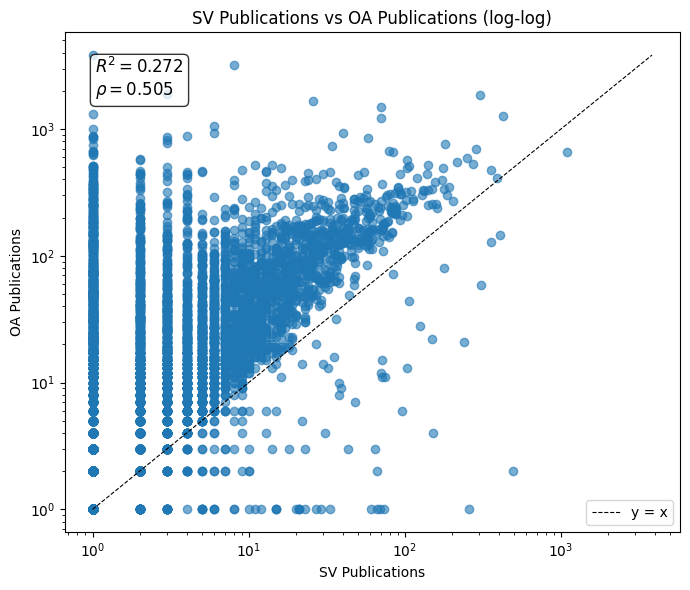

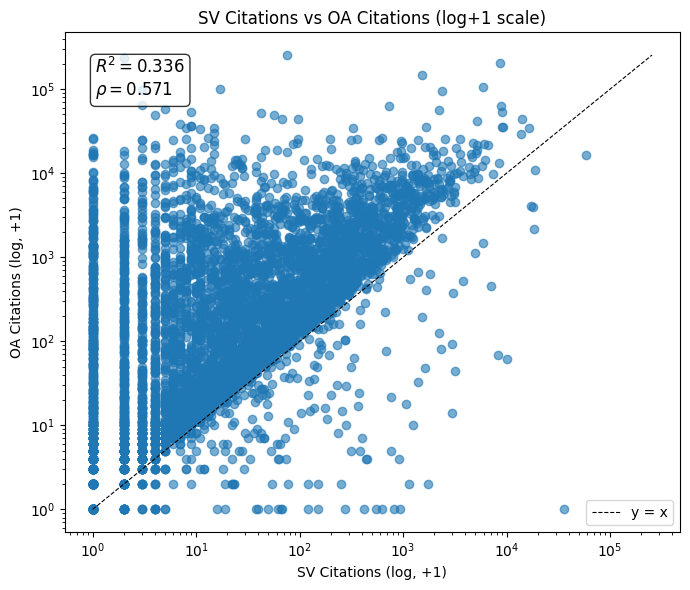

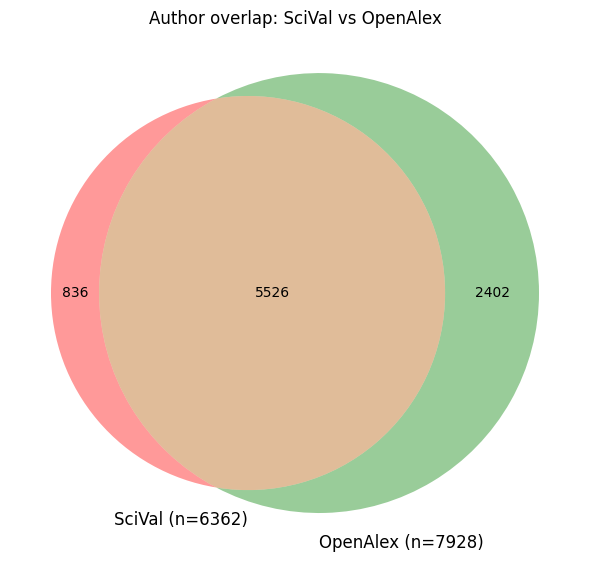

In [167]:
plot_match_diagnostics(sv_auths, oa_auths, combined_matches)

In [146]:
oa_unmatched.sort_values('Citations', ascending=False).head()

,OpenAlex ID,ORCID,Name,Alt Names,Publications,Citations,h-index,Number of Institutions,Topic,first_names,last_name,last_init,name_raw,id,fi_ln
2371,A5018419311,https://orcid.org/0000-0003-4776-5601,Salim Yusuf,"['AC Mattos', 'David Fitchett', 'J Potter', 'J...",2144,291160,262,448,Health Sciences,salim,yusuf,y,salim yusuf,A5018419311,s yusuf
407,A5100437036,https://orcid.org/0000-0002-6170-4744,Kai Wang,"['Anzhen Wang', 'Binyu Song', 'Di Lu', 'Feng R...",7226,216635,172,1314,Life Sciences,kai,wang,w,kai wang,A5100437036,k wang
2230,A5035068594,https://orcid.org/0000-0002-8321-9950,Mark A. Rubin,"['A. Orlin', 'Brian Van Tine', 'Deyou Zheng', ...",1541,167645,187,209,Health Sciences,mark a.,rubin,r,mark a. rubin,A5035068594,m rubin
1948,A5100399276,https://orcid.org/0000-0002-0166-1973,Han Zhang,"['Ahmed A. Al-Ghamdi', 'Chris Bowen', 'Dan He'...",3869,157203,184,809,Physical Sciences,han,zhang,z,han zhang,A5100399276,h zhang
642,A5034363861,https://orcid.org/0000-0001-5038-6210,Viswanathan Mohan,"['>V. Mohan', 'Amitabha Islam', 'B Mohan', 'B ...",1951,137822,145,166,Health Sciences,viswanathan,mohan,m,viswanathan mohan,A5034363861,v mohan


In [147]:
oa_auths_3 = oa_auths[oa_auths['Publications'] >= 3]
sv_auths_3 = sv_auths[sv_auths['Scholarly Output'] >= 3]

print("auths w/ 3+ pubs: ")
print(len(oa_auths_3))
print(len(sv_auths_3))

auths w/ 3+ pubs: 
6660
3240


In [148]:
combined_matches_3, sv_unmatched_3, oa_unmatched_3 = match_authors(sv_auths_3, oa_auths_3)

Pass 2: fi_ln: 100%|██████████| 25/25 [00:05<00:00,  4.57it/s]

Matched:      3049 pairs
  full_name:  2789
  fi_ln:      260
SV unmatched: 191 / 3240 (5.9%)
OA unmatched: 3611 / 6660 (54.2%)


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score,match_type,topic
0,tessa voth,tessa voth,57219852392,A5023747670,3,4,12,38,100,full_name,Life Sciences
1,nicholas vincent,nicholas vincent,57202044868,A5070837664,3,244,2,970,100,full_name,Social Sciences
2,william odom,william odom,6701770018,A5073024818,77,145,1623,5092,100,full_name,Physical Sciences
3,chang hoon oh,chang hoon oh,23390684900,A5010166639,34,153,1087,4294,100,full_name,Social Sciences
4,olga vishnyakova,olga vishnyakova,57572163400,A5052000561,3,44,3,127,100,full_name,Social Sciences
...,...,...,...,...,...,...,...,...,...,...,...
3044,zohreh dehghani,mostafa rahmani dehaghani,59284422200,A5004024668,3,36,4,219,86,fi_ln,Physical Sciences
3045,ge chang,anne lynn s. chang,57567754800,A5044978994,3,383,5,26140,86,fi_ln,Life Sciences
3046,randall randall kropp,p. randall kropp,24463266700,A5050932508,8,52,80,2781,86,fi_ln,Social Sciences
3047,ollie m blake,adam j. blake,35767452200,A5031527285,3,24,52,230,86,fi_ln,Life Sciences


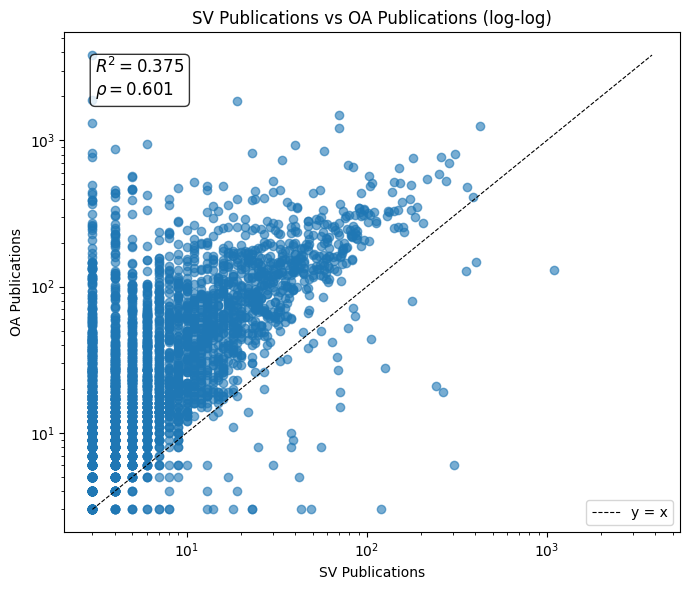

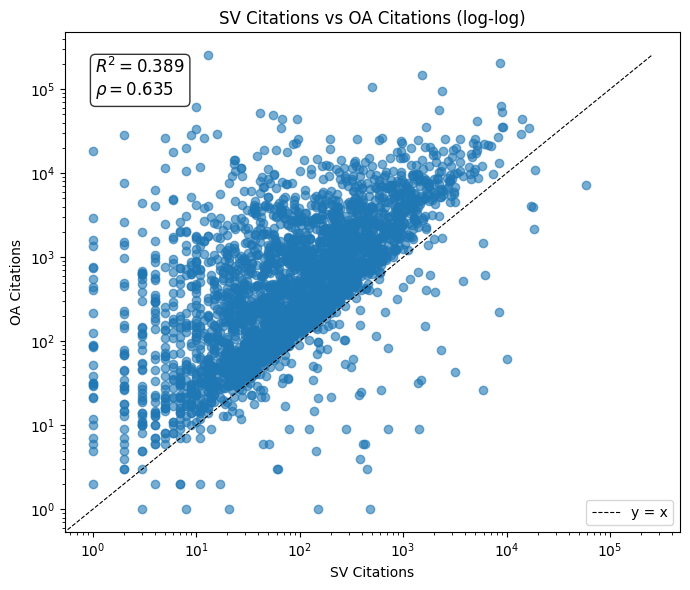

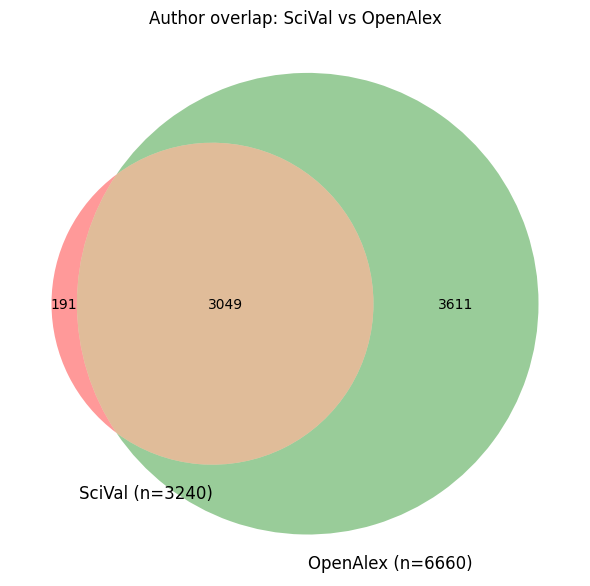

In [149]:
plot_match_diagnostics(sv_auths_3, oa_auths_3, combined_matches_3)

In [150]:
oa_auths_5 = oa_auths[oa_auths['Publications'] >= 5]
sv_auths_5 = sv_auths[sv_auths['Scholarly Output'] >= 5]

print("auths w/ 3+ pubs: ")
print(len(oa_auths_5))
print(len(sv_auths_5))

auths w/ 3+ pubs: 
5950
2220


In [151]:
combined_matches_5, sv_unmatched_5, oa_unmatched_5 = match_authors(sv_auths_5, oa_auths_5)

Pass 2: fi_ln: 100%|██████████| 24/24 [00:04<00:00,  5.88it/s]

Matched:      2100 pairs
  full_name:  1918
  fi_ln:      182
SV unmatched: 120 / 2220 (5.4%)
OA unmatched: 3850 / 5950 (64.7%)


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score,match_type,topic
0,nathalie vigouroux,nathalie vigouroux,25222212400,A5073793337,7,24,103,419,100,full_name,Physical Sciences
1,ravichandra venkateshappa,ravichandra venkateshappa,57218254792,A5054846185,7,18,45,166,100,full_name,Health Sciences
2,swetha venugopal,swetha venugopal,57190567404,A5076416027,6,13,165,260,100,full_name,Physical Sciences
3,naveen vedula,naveen vedula,57103817000,A5053898081,6,10,61,234,100,full_name,Physical Sciences
4,alexander vedrashko,alexander vedrashko,55670693600,A5005210233,5,23,146,464,100,full_name,Social Sciences
...,...,...,...,...,...,...,...,...,...,...,...
2095,nick sumner,william n. sumner,42162037900,A5043431516,6,39,44,617,88,fi_ln,Physical Sciences
2096,laurel laurel weldon,s. laurel weldon,12779890100,A5066094932,7,96,69,4314,88,fi_ln,Social Sciences
2097,shuvay singh,harman jit singh,59156749500,A5016613624,265,5,8423,15,86,fi_ln,Social Sciences
2098,randall randall kropp,p. randall kropp,24463266700,A5050932508,8,52,80,2781,86,fi_ln,Social Sciences


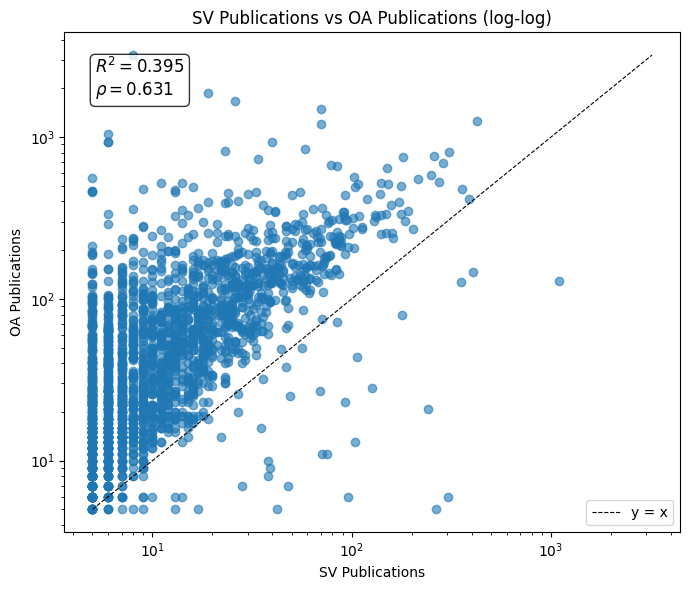

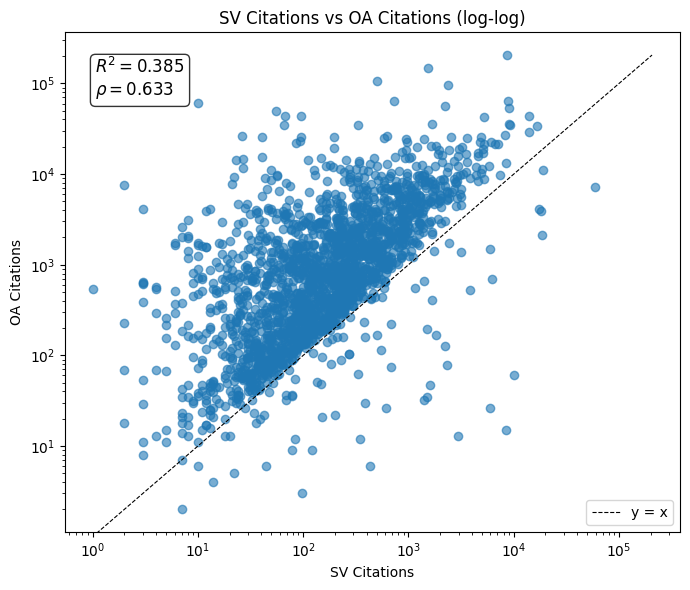

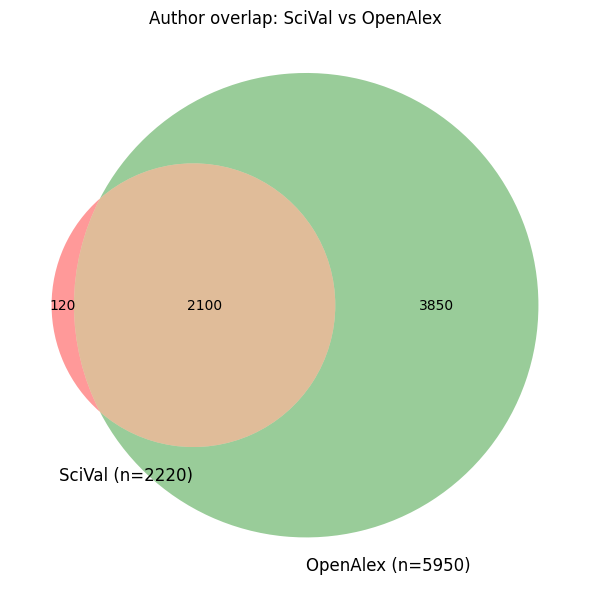

In [152]:
plot_match_diagnostics(sv_auths_5, oa_auths_5, combined_matches_5)

In [153]:
oa_auths['Number of Institutions'].unique()

print(len(oa_auths))
print(len(oa_auths[oa_auths['Number of Institutions'] <= 20]))

oa_inst_filter = oa_auths[oa_auths['Number of Institutions'] <= 20]


7928
6898


Pass 2: fi_ln: 100%|██████████| 27/27 [00:19<00:00,  1.39it/s]

Matched:      5153 pairs
  full_name:  4653
  fi_ln:      500
SV unmatched: 1209 / 6362 (19.0%)
OA unmatched: 1745 / 6898 (25.3%)


,sv_name,oa_name,sv_id,oa_id,sv_pubs,oa_pubs,sv_cited,oa_cited,similarity_score,match_type,topic
0,madhawa vidanapathirana,madhawa vidanapathirana,57196029837,A5085419917,2,8,38,8,100,full_name,Physical Sciences
1,natasha virginkar,natasha virginkar,57194332415,A5074408591,1,3,0,52,100,full_name,Health Sciences
2,omid vakili,omid vakili,57226456433,A5103241829,2,6,3,16,100,full_name,Health Sciences
3,natasha vitkin,natasha vitkin,57202210416,A5032369400,2,12,7,664,100,full_name,Social Sciences
4,stephanie vlachos,stephanie vlachos,57196816008,A5087294470,2,7,22,150,100,full_name,Life Sciences
...,...,...,...,...,...,...,...,...,...,...,...
5148,a t bunka,mary bunka,59197521400,A5089604487,1,14,7,166,86,fi_ln,Health Sciences
5149,ronald g barr,robin barrow,7401833153,A5020422884,1,135,14,1231,86,fi_ln,Social Sciences
5150,diego s silva,luiz pereira da silva,35738098800,A5070670231,15,42,216,1516,86,fi_ln,Health Sciences
5151,kevin huang,fiona yutong huang,57703648800,A5024028275,1,1,13,9,86,fi_ln,Life Sciences


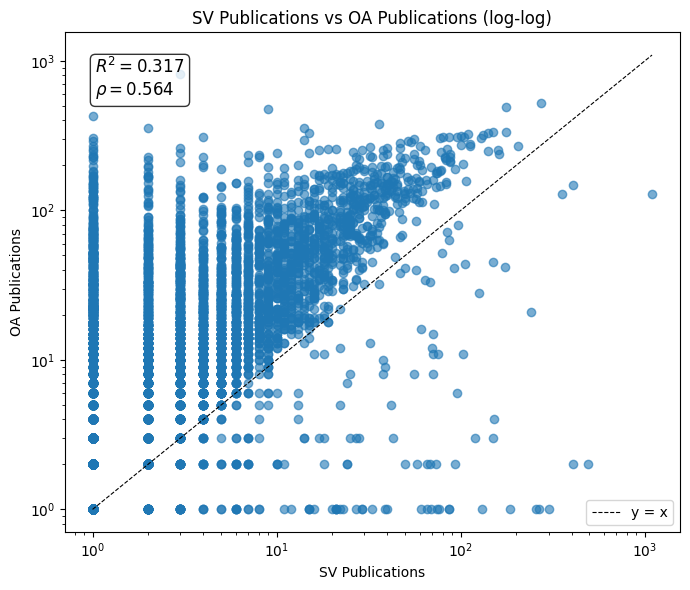

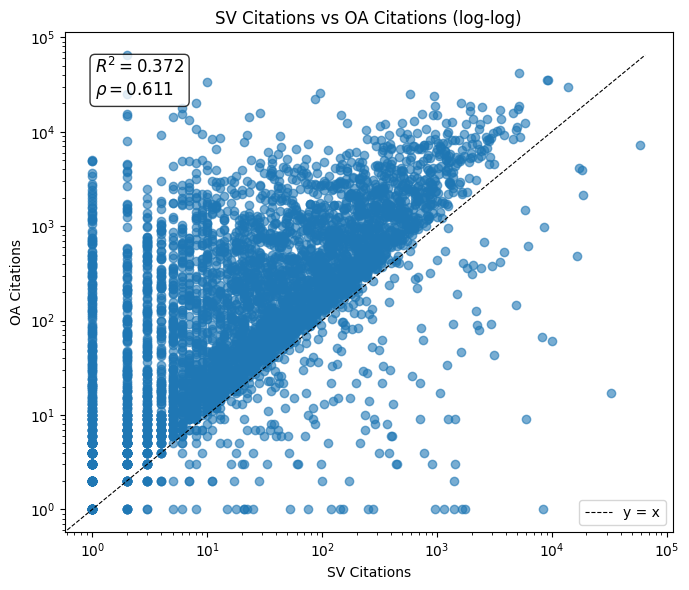

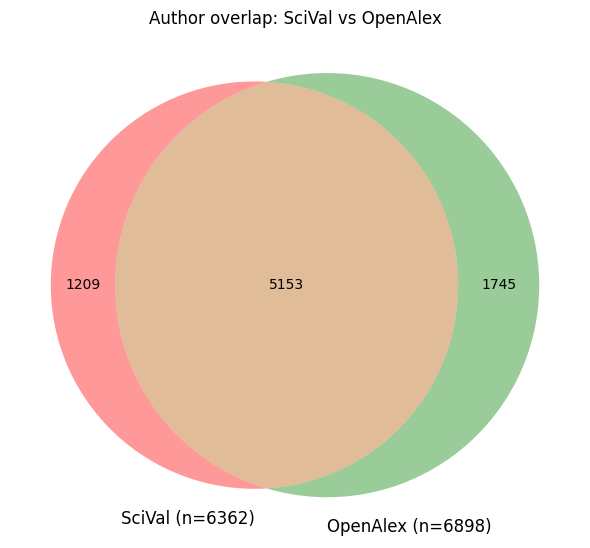

In [154]:
combined_matches_filt, sv_unmatched_filt, oa_unmatched_filt = match_authors(sv_auths, oa_inst_filter)
plot_match_diagnostics(sv_auths, oa_inst_filter, combined_matches_filt)

In [155]:
#list(oa_unmatched.sort_values(by='Citations', ascending=False)['Name'])[1000:1200]

### Daniel Daly-Grafstein

In [156]:
sv_auths[sv_auths['Scopus author ID']==57207102541]

,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches,fi_ln


### Deborah Harford

In [157]:
sv_auths[sv_auths['Scopus author ID']==56582183700]

,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches,fi_ln


### Marie Rekkas

In [158]:
sv_auths[sv_auths['Scopus author ID']==8346843600]

,Name,Scholarly Output,Most recent publication,Citations,Citations per Publication,Field-Weighted Citation Impact,h-index,Scopus author ID,Scopus author profile,Primary author affiliation*,last_name,last_init,first_names,name_raw,potential_matches,fi_ln


### Discipline sorting

In [159]:
oa_auths['Topic'].unique()

array(['Health Sciences', 'Life Sciences', 'Physical Sciences',
       'Social Sciences', nan], dtype=object)

#### health sci

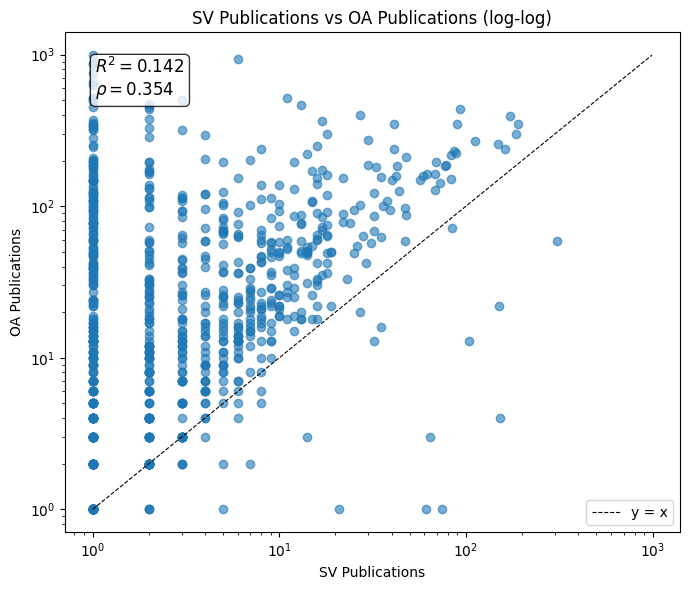

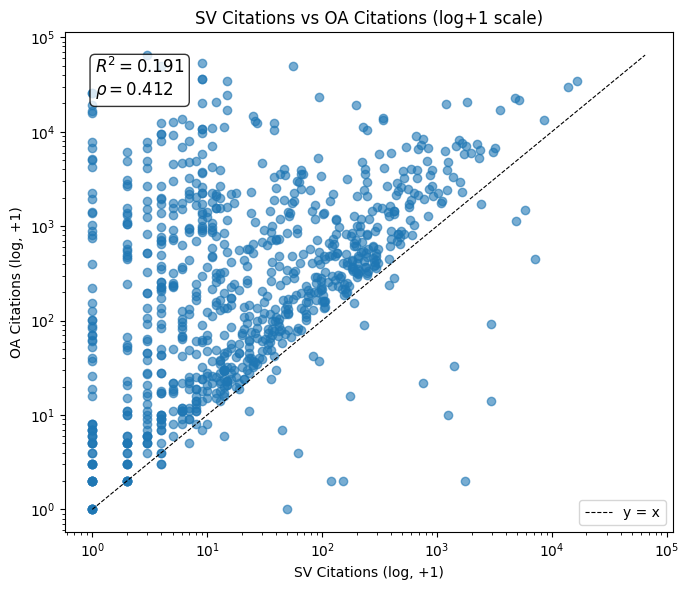

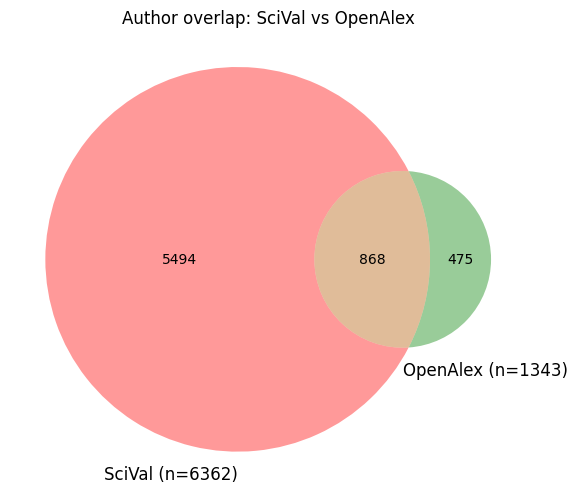

In [168]:
sv_health = sv_auths
oa_health = oa_auths[oa_auths['Topic']=='Health Sciences']
combined_health = combined_matches[combined_matches['topic']=='Health Sciences']

plot_match_diagnostics(sv_health, oa_health, combined_health)

In [172]:
print(len(combined_health))

868


#### life sci

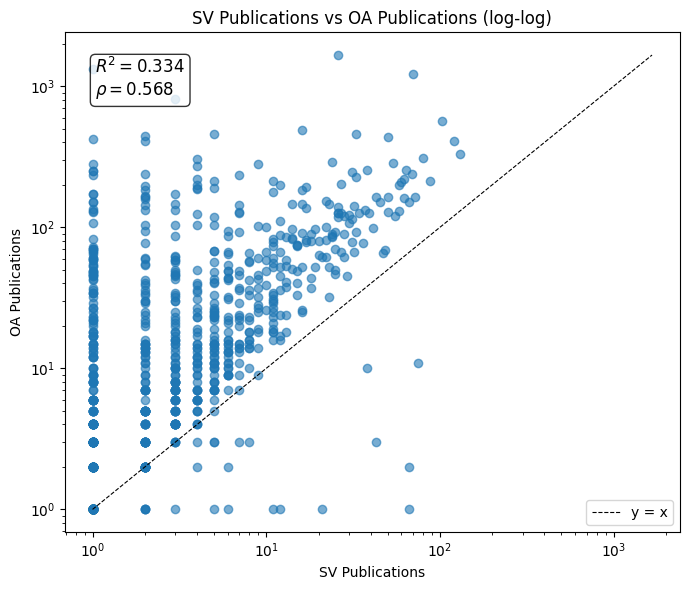

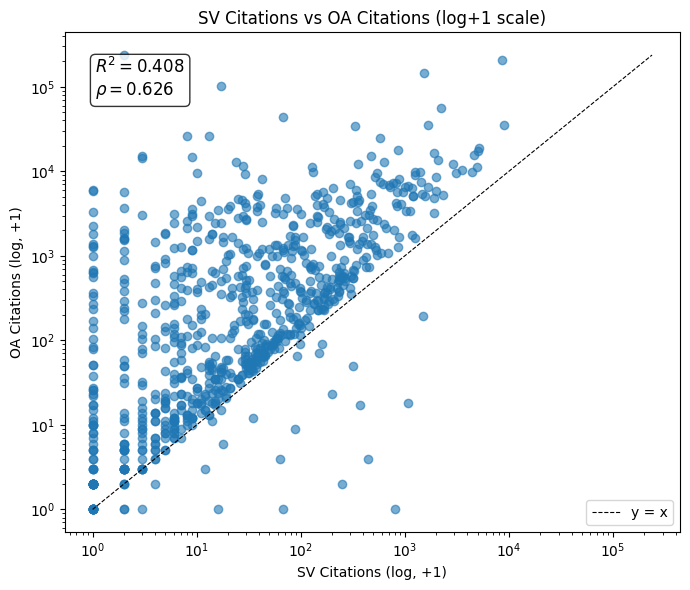

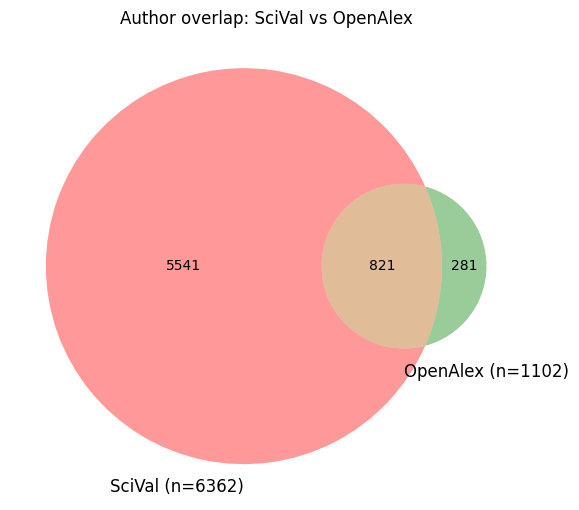

In [169]:
sv_life = sv_auths
oa_life = oa_auths[oa_auths['Topic']=='Life Sciences']
combined_life = combined_matches[combined_matches['topic']=='Life Sciences']

plot_match_diagnostics(sv_life, oa_life, combined_life)

In [174]:
print(len(combined_life))

821


#### physical sci

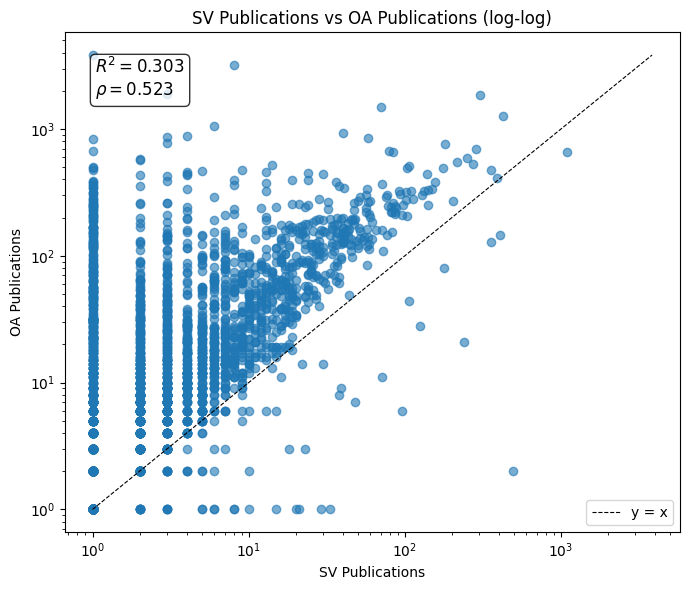

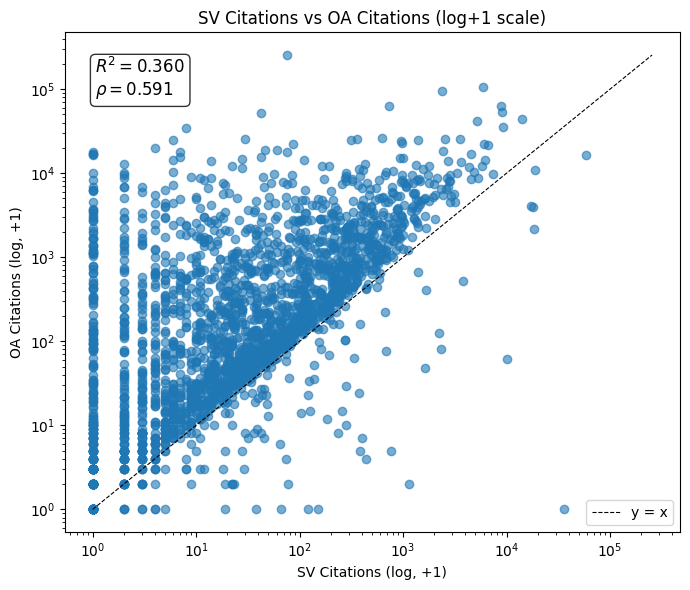

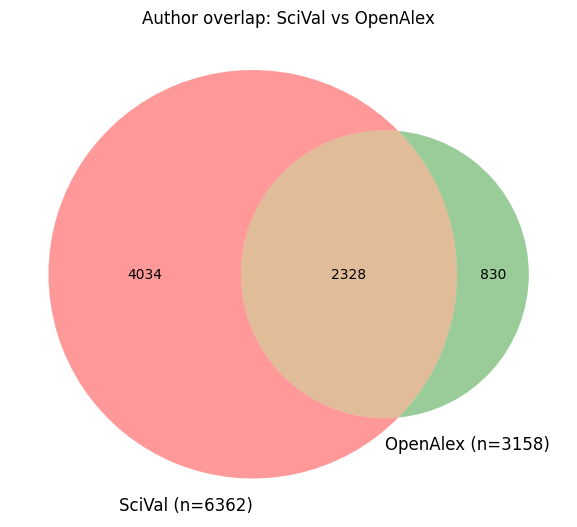

In [162]:
sv_physical = sv_auths
oa_physical = oa_auths[oa_auths['Topic']=='Physical Sciences']
combined_physical = combined_matches[combined_matches['topic']=='Physical Sciences']

plot_match_diagnostics(sv_physical, oa_physical, combined_physical)

In [175]:
print(len(combined_physical))

2328


#### social sci

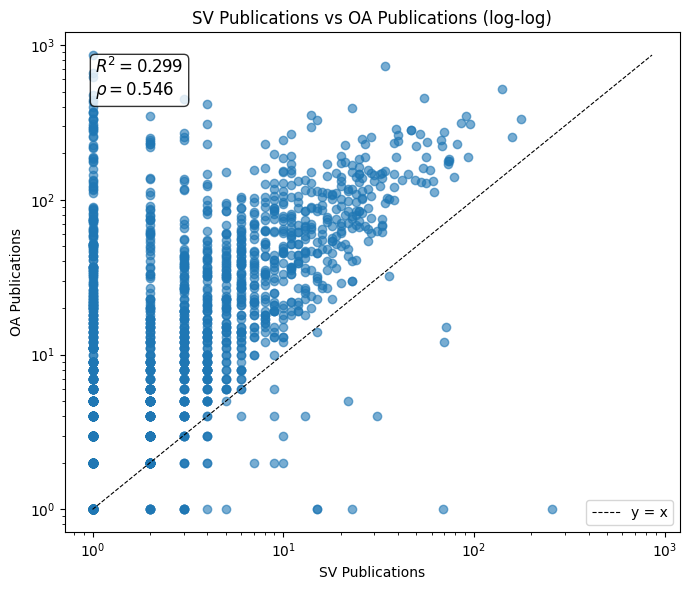

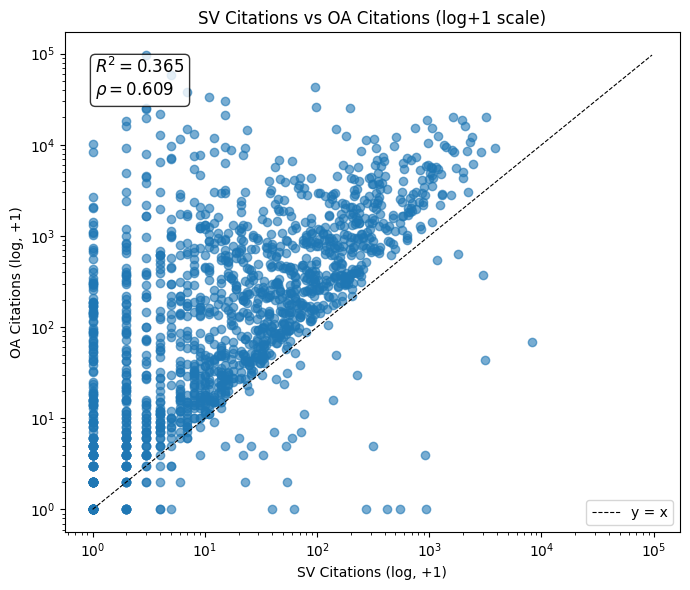

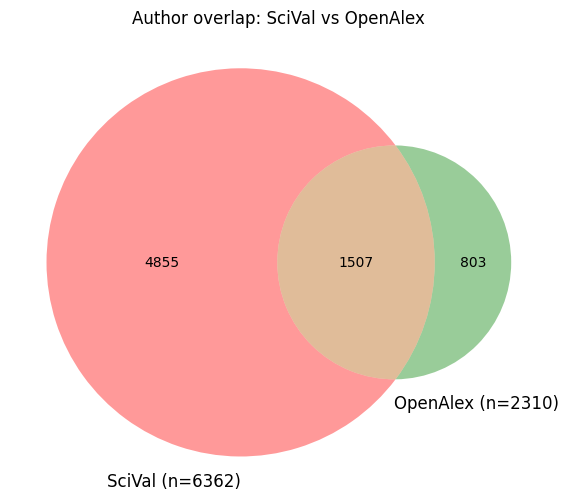

In [171]:
sv_social = sv_auths
oa_social = oa_auths[oa_auths['Topic']=='Social Sciences']
combined_social = combined_matches[combined_matches['topic']=='Social Sciences']

plot_match_diagnostics(sv_social, oa_social, combined_social)

In [176]:
print(len(combined_social))

1507
